In [ ]:
import tensorflow as tf
import os
import random
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
var1 = x_train.shape[0]
var2 = y_train.shape[0]
var3 = x_test.shape[0]
var4 = y_test.shape[0]
print("x_train has " + str(var1) + " samples")
print("y_train has " + str(var2) + " samples")
print("x_test has " + str(var3) + " samples")
print("y_test has " + str(var4) + " samples")

x_train has 60000 samples
y_train has 60000 samples
x_test has 10000 samples
y_test has 10000 samples


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


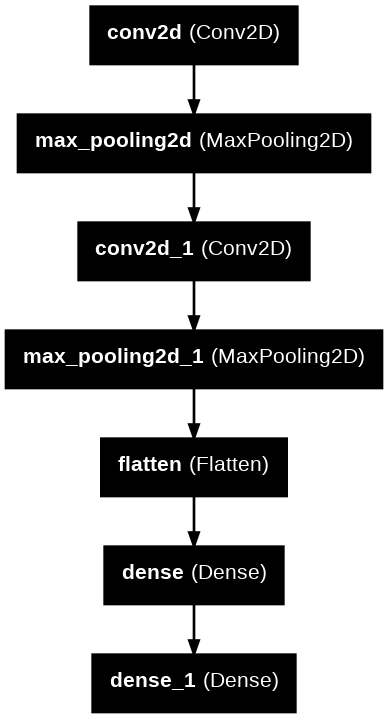

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tf.keras.utils.plot_model(
    model,
    to_file="img_model.png",
    show_shapes=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=96,
)

In [ ]:
history = model.fit(x_train, y_train, batch_size=32, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.8949 - loss: 1.2728 - val_accuracy: 0.9772 - val_loss: 0.0722
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9810 - loss: 0.0606 - val_accuracy: 0.9819 - val_loss: 0.0600
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9867 - loss: 0.0439 - val_accuracy: 0.9843 - val_loss: 0.0488


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
The result for image 6514 is probably: 8


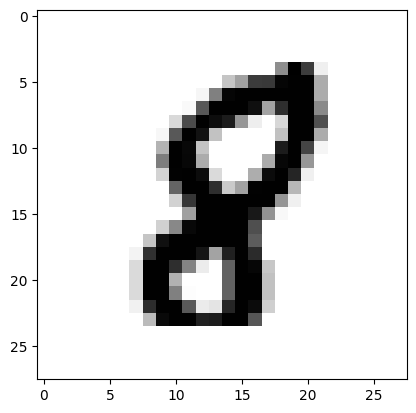

In [ ]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
train_images = train_images.astype('float32') / 255.0

n = random.randint(0, len(test_images))
for i in range(1):
    img = test_images[n]
    img = img.reshape((1, 28, 28, 1))
    prediction = model.predict(img)
    predicted_digit = np.argmax(prediction)
    print(f'The result for image {n} is probably: {predicted_digit}')
    plt.imshow(test_images[n], cmap=plt.cm.binary)
    plt.show()

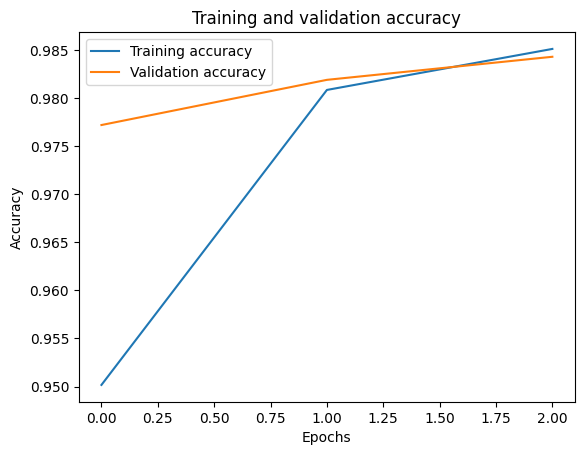

In [ ]:
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

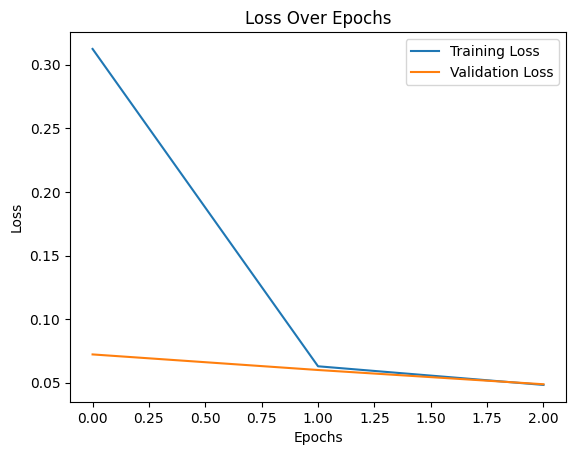

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("model.weights.h5")
print("Saved model to disk")

Saved model to disk


In [ ]:
# Load the model
json_file = open('model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()

loaded_model = model_from_json(loaded_model_json)
loaded_model.load_weights("model.weights.h5")
print("Loaded model from disk")

Loaded model from disk


In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(accuracy)
print(loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9804 - loss: 0.0597
0.9843000173568726
0.04878966510295868
